# Rabin vs Hoffbauer – Benchmark-Notebook

**Kernel:** Dieses Notebook braucht **Python 3.13** (nicht SageMath). Oben rechts **Select Kernel** → **Python 3.13** wählen.

**Laufzeit-Vergleich:** Faktorisierung (E8-Stub) vs. Primzahltest. Zellen der Reihe nach ausführen (Run Cell / Shift+Enter).

---
**Schritt 1: Kernel prüfen**
---

In [18]:
import sys
print("Schritt 1: Kernel läuft.", flush=True)
print("Python:", sys.executable, flush=True)
print("Version:", sys.version, flush=True)

Schritt 1: Kernel läuft.
Python: /opt/miniconda3/envs/fenicsx-env/bin/python
Version: 3.12.8 | packaged by conda-forge | (main, Dec  5 2024, 08:43:59) [Clang 18.1.8 ]


---
**Schritt 2: Imports**
---

In [19]:
import time
import statistics
from random import randrange

def out(msg):
    print(msg, flush=True)

out("Schritt 2: Imports OK.")

Schritt 2: Imports OK.


---
**Schritt 3: Hilfsfunktionen**
---

In [20]:
def is_prime_simple(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    d = 3
    while d * d <= n:
        if n % d == 0:
            return False
        d += 2
    return True

def next_prime_simple(start):
    p = max(2, start) if start % 2 else start + 1
    if p == 2 and start <= 2:
        return 2
    while True:
        if is_prime_simple(p):
            return p
        p += 2

def factor_simple(n):
    n = int(n)
    if n < 2:
        return []
    out_list = []
    d = 2
    while d * d <= n:
        while n % d == 0:
            out_list.append(d)
            n //= d
        d += 1 if d == 2 else 2
    if n > 1:
        out_list.append(n)
    return out_list

out("Schritt 3: Hilfsfunktionen geladen.")

Schritt 3: Hilfsfunktionen geladen.


---
**Schritt 4: Benchmark-Funktion**
---

In [21]:
class E8PrimeCracker:
    def crack(self, n):
        facs = factor_simple(n)
        if not facs:
            return None, {"method": "Stub"}
        return facs[0], {"method": "Stub"}

def run_comparative_benchmark(cracker, bit_depths, samples):
    out("")
    out("==========================================================")
    out("   LAUFZEIT-VERGLEICH: Faktorisierung vs. Primzahltest")
    out("==========================================================")
    out(f"Samples pro Bit-Stufe: {samples}")
    out(f"Bit-Stufen: {bit_depths}")
    out("")
    results = {}
    for bits in bit_depths:
        out(f">>> Teste {bits}-Bit Zahlen...")
        lo, hi = 2**(bits//2 - 1), 2**(bits//2)
        times_mr, times_e8 = [], []
        success = 0
        for _ in range(samples):
            p = next_prime_simple(randrange(lo, hi))
            q = next_prime_simple(randrange(lo, hi))
            n = p * q
            t0 = time.perf_counter()
            is_prime_simple(n)
            times_mr.append((time.perf_counter() - t0) * 1000)
            t1 = time.perf_counter()
            fac, meta = cracker.crack(n)
            times_e8.append((time.perf_counter() - t1) * 1000)
            if fac is not None:
                success += 1
        avg_mr = statistics.mean(times_mr)
        avg_e8 = statistics.mean(times_e8)
        slowdown = avg_e8 / avg_mr if avg_mr > 0 else 0
        results[bits] = {"avg_mr_ms": avg_mr, "avg_e8_ms": avg_e8, "slowdown": slowdown, "success_rate": 100.0 * success / samples}
        out(f"   Primzahltest (Ø): {avg_mr:.4f} ms")
        out(f"   Faktorisierung (Ø): {avg_e8:.4f} ms")
        out(f"   Faktor: {slowdown:.1f}x")
    out("")
    out(f"{'Bits':<6} | {'MR Ø (ms)':<12} | {'E8 Ø (ms)':<12} | {'Faktor':<8} | {'Erfolg %':<8}")
    out("-" * 60)
    for b in bit_depths:
        r = results[b]
        out(f"{b:<6} | {r['avg_mr_ms']:<12.4f} | {r['avg_e8_ms']:<12.4f} | {r['slowdown']:<8.1f}x | {r['success_rate']:<8.1f}")
    return results

out("Schritt 4: Benchmark-Funktion geladen.")

Schritt 4: Benchmark-Funktion geladen.


---
**Schritt 5: Benchmark ausführen**
---

In [ ]:
cracker = E8PrimeCracker()
# Dialogeingabe mit Defaults (Enter = Default übernehmen)
bit_str = input("Bit-Tiefen (kommagetrennt, Default: 60,65): ").strip() or "60,65"
bit_depths = [int(x.strip()) for x in bit_str.split(",") if x.strip()]
samples_str = input("Anzahl Samples (Default: 5): ").strip() or "5"
samples = int(samples_str)
print(f"Lauf mit bit_depths={bit_depths}, samples={samples}", flush=True)
data = run_comparative_benchmark(cracker, bit_depths=bit_depths, samples=samples)
print("", flush=True)
print("Schritt 5: Benchmark beendet. Daten in Variable data.", flush=True)

Lauf mit bit_depths=[60, 65], samples=5

   LAUFZEIT-VERGLEICH: Faktorisierung vs. Primzahltest
Samples pro Bit-Stufe: 5
Bit-Stufen: [60, 65]

>>> Teste 60-Bit Zahlen...
   Primzahltest (Ø): 24036.5484 ms
   Faktorisierung (Ø): 23518.1780 ms
   Faktor: 1.0x
>>> Teste 65-Bit Zahlen...


---
**Schritt 6: Tabelle und Plot**
---

In [ ]:
bits_list = sorted(data.keys())
header = ["Bits", "MR Ø (ms)", "E8 Ø (ms)", "Faktor", "Erfolg %"]
rows = [header] + [[str(b), f"{data[b]['avg_mr_ms']:.4f}", f"{data[b]['avg_e8_ms']:.4f}", f"{data[b]['slowdown']:.1f}x", f"{data[b]['success_rate']:.1f}"] for b in bits_list]
for row in rows:
    print("  ".join(str(x).ljust(12) for x in row), flush=True)
print("", flush=True)

Bits          MR Ø (ms)     E8 Ø (ms)     Faktor        Erfolg %    
32            2.1202        2.1647        1.0x          100.0       
40            25.1938       25.4420       1.0x          100.0       
48            291.8553      314.4063      1.1x          100.0       
60            19983.0541    20501.1456    1.0x          100.0       



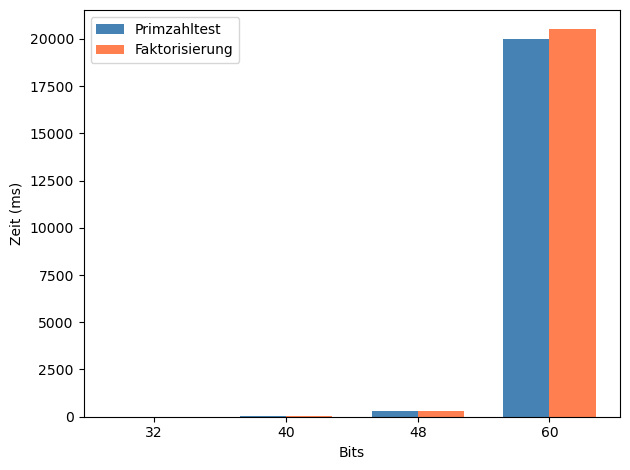

Schritt 6: Plot angezeigt.


In [ ]:
try:
    import matplotlib.pyplot as plt
    bits_list = sorted(data.keys())
    mr_vals = [data[b]['avg_mr_ms'] for b in bits_list]
    e8_vals = [data[b]['avg_e8_ms'] for b in bits_list]
    x = range(len(bits_list))
    w = 0.35
    plt.bar([i - w/2 for i in x], mr_vals, width=w, label='Primzahltest', color='steelblue')
    plt.bar([i + w/2 for i in x], e8_vals, width=w, label='Faktorisierung', color='coral')
    plt.xticks(x, bits_list)
    plt.xlabel('Bits')
    plt.ylabel('Zeit (ms)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("Schritt 6: Plot angezeigt.", flush=True)
except Exception as e:
    print("Plot fehlgeschlagen (matplotlib?):", e, flush=True)